# 02 — Modelagem: GLM (freq × sev) → prêmio puro, e GLM vs GBM + SHAP

Continuação da [EDA](01_eda.ipynb). Aqui consolidamos a modelagem **importando o motor** (`src/pricing`) — o notebook conta a história, o código vive em um lugar só.

**Roteiro:** frequência (Poisson) → severidade (Gamma) → prêmio puro (freq×sev vs Tweedie) → explicabilidade (GLM vs GBM + SHAP).

In [1]:
import sys, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import mean_poisson_deviance, mean_gamma_deviance, mean_tweedie_deviance

ROOT = None
for base in [pathlib.Path('.'), pathlib.Path('..')]:
    if (base / 'src' / 'pricing').exists():
        ROOT = base.resolve()
        break
sys.path.insert(0, str(ROOT))

from src.pricing.data import CATEGORICAL, NUMERIC
from src.pricing.frequency import build_frequency_pipeline
from src.pricing.severity import build_severity_pipeline
from src.pricing.pure_premium import build_tweedie_pipeline
from src.pricing.gbm import build_frequency_gbm

plt.rcParams['figure.figsize'] = (7, 4)
plt.rcParams['axes.grid'] = True

proc = ROOT / 'data' / 'processed'
def load(name):
    pq = proc / (name + '.parquet')
    cs = proc / (name + '.csv')
    return pd.read_parquet(pq) if pq.exists() else pd.read_csv(cs)

df = load('freMTPL2_modeling')

# X unificado: categoricas em codigo ordinal (GLM faz one-hot, GBM trata nativo)
enc = OrdinalEncoder(dtype=np.float64)
X = df[CATEGORICAL + NUMERIC].copy()
X[CATEGORICAL] = enc.fit_transform(df[CATEGORICAL])

train_idx, test_idx = train_test_split(df.index, test_size=0.2, random_state=42)
Xtr, Xte = X.loc[train_idx], X.loc[test_idx]
tr, te = df.loc[train_idx], df.loc[test_idx]
print('Treino:', f'{len(tr):,}', '| Teste:', f'{len(te):,}')

Treino: 542,410 | Teste: 135,603


## 1. Frequência — GLM Poisson

Modelamos a taxa `ClaimNb / Exposure` com a exposição como peso (offset). Métrica: *mean Poisson deviance* (menor = melhor), contra a média ingênua da carteira.

In [2]:
glm_f = build_frequency_pipeline()
glm_f.fit(Xtr, tr['Frequency'], glm__sample_weight=tr['Exposure'])
pred_f = glm_f.predict(Xte)

base_f = np.average(tr['Frequency'], weights=tr['Exposure'])
d_naive = mean_poisson_deviance(te['Frequency'], np.full(len(te), base_f), sample_weight=te['Exposure'])
d_glm = mean_poisson_deviance(te['Frequency'], pred_f, sample_weight=te['Exposure'])

pd.DataFrame({
    'Modelo': ['Media ingenua', 'GLM Poisson'],
    'Poisson deviance': [round(d_naive, 5), round(d_glm, 5)],
    'vs ingenua': ['-', f'{(d_naive - d_glm) / d_naive * 100:+.2f}%'],
})

,Modelo,Poisson deviance,vs ingenua
0,Media ingenua,0.62738,-
1,GLM Poisson,0.60874,+2.97%


## 2. Severidade — GLM Gamma

Apenas apólices com sinistro; alvo `ClaimAmount / ClaimNb` (custo médio por sinistro), peso `ClaimNb`. A Gamma capta a assimetria à direita vista na EDA.

In [3]:
m_tr = (tr['ClaimNb'] > 0) & (tr['ClaimAmount'] > 0)
sev_tr = tr[m_tr]
sev_ytr = sev_tr['ClaimAmount'] / sev_tr['ClaimNb']

glm_s = build_severity_pipeline()
glm_s.fit(Xtr.loc[sev_tr.index], sev_ytr, glm__sample_weight=sev_tr['ClaimNb'])

m_te = (te['ClaimNb'] > 0) & (te['ClaimAmount'] > 0)
sev_te = te[m_te]
sev_yte = sev_te['ClaimAmount'] / sev_te['ClaimNb']
pred_s = glm_s.predict(Xte.loc[sev_te.index])

base_s = np.average(sev_ytr, weights=sev_tr['ClaimNb'])
ds_naive = mean_gamma_deviance(sev_yte, np.full(len(sev_te), base_s), sample_weight=sev_te['ClaimNb'])
ds_glm = mean_gamma_deviance(sev_yte, pred_s, sample_weight=sev_te['ClaimNb'])

print(f'Severidade media (treino): {base_s:,.0f} EUR/sinistro')
pd.DataFrame({
    'Modelo': ['Media ingenua', 'GLM Gamma'],
    'Gamma deviance': [round(ds_naive, 4), round(ds_glm, 4)],
})

Severidade media (treino): 2,287 EUR/sinistro


,Modelo,Gamma deviance
0,Media ingenua,1.6351
1,GLM Gamma,1.7753


## 3. Prêmio puro — freq × severidade vs Tweedie direto

Duas rotas até `E[freq] × E[sev]`. Avaliamos com *Tweedie deviance* (p=1,9) e uma **calibração de carteira** (total previsto / total real → ideal ≈ 1).

In [4]:
pp_product = glm_f.predict(Xte) * glm_s.predict(Xte)

tw = build_tweedie_pipeline(power=1.9)
tw.fit(Xtr, tr['PurePremium'], glm__sample_weight=tr['Exposure'])
pp_tweedie = tw.predict(Xte)

base_pp = np.average(tr['PurePremium'], weights=tr['Exposure'])
pp_base = np.full(len(te), base_pp)

ytrue = te['PurePremium'].to_numpy()
wexp = te['Exposure'].to_numpy()
total_actual = float(te['ClaimAmount'].sum())

def linha(nome, pred):
    dev = mean_tweedie_deviance(ytrue, pred, sample_weight=wexp, power=1.9)
    calib = float(np.sum(pred * wexp)) / total_actual
    return {'Abordagem': nome, 'Tweedie deviance': round(dev, 2), 'Total prev/real': round(calib, 2)}

pd.DataFrame([
    linha('Media ingenua', pp_base),
    linha('Frequencia x Severidade', pp_product),
    linha('Tweedie direto', pp_tweedie),
])

,Abordagem,Tweedie deviance,Total prev/real
0,Media ingenua,34.80,1.01
1,Frequencia x Severidade,34.69,1.33
2,Tweedie direto,34.46,1.04


> **Insight:** o produto freq×severidade *ranqueia* o risco, mas costuma **descalibrar o total da carteira** (cauda pesada da severidade), enquanto o **Tweedie direto** fica melhor calibrado. É o trade-off precisão × calibração no centro do pricing.

## 4. Explicabilidade — GLM vs GBM + SHAP

O GBM (HistGradientBoosting, Poisson) é mais preciso, porém opaco. O SHAP abre a caixa-preta e mostra **em quais drivers** ele se apoia — e se batem com o GLM (transparente).

In [5]:
gbm = build_frequency_gbm()
gbm.fit(Xtr, tr['Frequency'], sample_weight=tr['Exposure'])
pred_gbm = gbm.predict(Xte)
d_gbm = mean_poisson_deviance(te['Frequency'], pred_gbm, sample_weight=te['Exposure'])

tabela = pd.DataFrame({
    'Modelo': ['Media ingenua', 'GLM Poisson', 'GBM Poisson'],
    'Poisson deviance': [round(d_naive, 5), round(d_glm, 5), round(d_gbm, 5)],
    'vs ingenua': ['-', f'{(d_naive-d_glm)/d_naive*100:+.2f}%', f'{(d_naive-d_gbm)/d_naive*100:+.2f}%'],
})
print(f'GBM bate o GLM em {(d_glm-d_gbm)/d_glm*100:+.2f}% de deviance')
tabela

GBM bate o GLM em +5.15% de deviance


,Modelo,Poisson deviance,vs ingenua
0,Media ingenua,0.62738,-
1,GLM Poisson,0.60874,+2.97%
2,GBM Poisson,0.57737,+7.97%


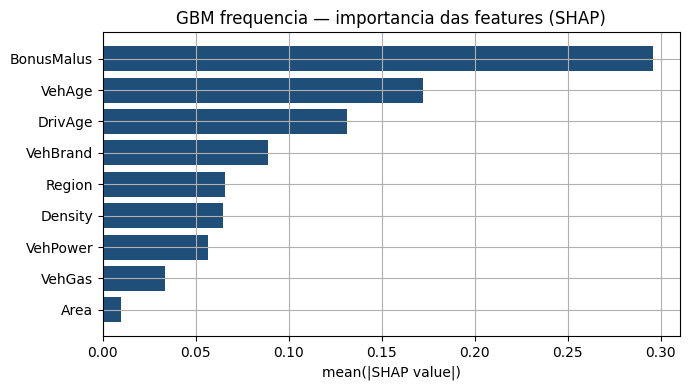

,feature,mean|SHAP|
0,BonusMalus,0.29569
1,VehAge,0.17205
2,DrivAge,0.13143
3,VehBrand,0.08877
4,Region,0.06555
5,Density,0.06478
6,VehPower,0.05631
7,VehGas,0.03368
8,Area,0.00975


In [6]:
import shap

sample = Xte.sample(n=300, random_state=0)
try:
    sv = shap.TreeExplainer(gbm)(sample, check_additivity=False)
    shap_vals = np.asarray(sv.values)
except Exception:
    shap_vals = np.asarray(shap.Explainer(gbm.predict, Xtr.sample(80, random_state=1))(sample).values)

feats = CATEGORICAL + NUMERIC
mean_abs = np.abs(shap_vals).mean(axis=0)
order = np.argsort(mean_abs)

plt.barh([feats[i] for i in order], mean_abs[order], color='#1f4e79')
plt.xlabel('mean(|SHAP value|)')
plt.title('GBM frequencia — importancia das features (SHAP)')
plt.tight_layout()
plt.show()

pd.DataFrame({'feature': [feats[i] for i in order[::-1]],
              'mean|SHAP|': np.round(mean_abs[order[::-1]], 5)})

## 5. Conclusões da v1

- **Frequência** (Poisson) e **severidade** (Gamma) batem o baseline ingênuo; combinadas dão o **prêmio puro**.
- **Tweedie direto** vence o produto freq×sev em deviance **e** em calibração de carteira → maturidade de pricing.
- O **GBM** ganha precisão sobre o GLM, e o **SHAP** mostra que usa os **mesmos drivers coerentes** (BonusMalus, idade do veículo/condutor) → ganho **confiável, não espúrio**.
- Trade-off central: **GLM transparente** (regulatório) vs **GBM preciso** (com SHAP para auditar).

**Próximos (v2+):** feature engineering, demo Streamlit, elasticidade/otimização (base ES), MLOps e score territorial BR.